In [1]:
from pathlib import Path
import kinodata
_ROOT = Path(kinodata.__file__).parent.parent
_MODEL = _ROOT / "models"
_DATA = _ROOT / "data"
_PROBING_DATA = _DATA / "probing"

print(f"Root directory: {_ROOT}")
print(f"Model directory: {_MODEL}")
print(f"Data directory: {_DATA}")
print(f"Probing data directory: {_PROBING_DATA}")


Root directory: /home/famo00001/kinodata-3D-affinity-prediction
Model directory: /home/famo00001/kinodata-3D-affinity-prediction/models
Data directory: /home/famo00001/kinodata-3D-affinity-prediction/data
Probing data directory: /home/famo00001/kinodata-3D-affinity-prediction/data/probing


In [3]:
import os
print(os.getcwd())
# os.chdir('/home/fatemeh/thesis/kinodata-3D-affinity-prediction')
# print(os.getcwd())

/home/famo00001/kinodata-3D-affinity-prediction/prob


In [4]:
# import kinodata-3d-affinity-prediction
import kinodata
from kinodata.data import KinodataDocked
from kinodata.transform import TransformToComplexGraph
from kinodata.data.data_module import make_kinodata_module
from kinodata.data.data_split import Split
from kinodata.types import *
import kinodata.configuration as cfg
from kinodata.model import ComplexTransformer, RegressionModel
from kinodata.model.complex_transformer import make_model as make_complex_transformer


import torch
from torch_geometric.loader import DataLoader
from pytorch_lightning import Trainer

import json
from pathlib import Path
import os
from typing import Any
from functools import partial
from collections import defaultdict


import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
from tqdm import tqdm
import random

from rdkit.Chem import PandasTools
from rdkit import Chem
from rdkit.Chem import Descriptors

!wandb disabled

W&B disabled.


# Original Dataset

Whole KinodataDocked dataset:

In [4]:
data = KinodataDocked(transform=TransformToComplexGraph(remove_heterogeneous_representation=False),
                      use_multiprocessing=True,
                      num_processes= os.cpu_count())

In [6]:
data[0]

HeteroData(
  y=[1],
  docking_score=[1],
  posit_prob=[1],
  predicted_rmsd=[1],
  pocket_sequence='KPLGRGAFGQVIEVAVKMLALMSELKILIHIGLNVVNLLGAMVIVEFCKFGNLSTYLRSFLASRKCIHRDLAARNILLICDFGLA',
  scaffold='C1CCC(CC2CCC(CC3CCCC4CCCCC43)CC2)CC1',
  activity_type='pIC50',
  ident=[1],
  smiles='c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1',
  ligand={
    z=[24],
    x=[24, 12],
    pos=[24, 3],
  },
  pocket={
    z=[652],
    x=[652, 12],
    pos=[652, 3],
  },
  pocket_residue={ x=[85, 23] },
  complex={
    x=[676, 12],
    z=[676],
    pos=[676, 3],
  },
  (ligand, bond, ligand)={
    edge_index=[2, 54],
    edge_attr=[54, 4],
  },
  (pocket, bond, pocket)={
    edge_index=[2, 1308],
    edge_attr=[1308, 4],
  },
  (complex, bond, complex)={
    edge_index=[2, 1362],
    edge_attr=[1362, 4],
  }
)

In [ ]:
from kinodata.configuration import load_from_file

Load the saved first 10 PyGs:

In [16]:
data_10  = torch.load("data/probing/10subset_data.pt", weights_only=False)

## Loader (Batching)

In [ ]:
# This is a simpler Loader than make_kinodata_module
# That one made my kernel crash
# batch_size = len(data)
batch_size = 50
data_module = DataLoader(data, batch_size= batch_size, shuffle=False, num_workers=os.cpu_count()) 
# data_module = DataLoader(data_10, batch_size=10, shuffle=False, num_workers=12)

In [8]:
dataset = next(iter(data_module))
print(type(dataset))
dataset

<class 'abc.HeteroDataBatch'>


HeteroDataBatch(
  y=[100],
  docking_score=[100],
  posit_prob=[100],
  predicted_rmsd=[100],
  pocket_sequence=[100],
  scaffold=[100],
  activity_type=[100],
  ident=[100],
  smiles=[100],
  ligand={
    z=[2565],
    x=[2565, 12],
    pos=[2565, 3],
    batch=[2565],
    ptr=[101],
  },
  pocket={
    z=[65431],
    x=[65431, 12],
    pos=[65431, 3],
    batch=[65431],
    ptr=[101],
  },
  pocket_residue={
    x=[8500, 23],
    batch=[8500],
    ptr=[101],
  },
  complex={
    x=[67996, 12],
    z=[67996],
    pos=[67996, 3],
    batch=[67996],
    ptr=[101],
  },
  (ligand, bond, ligand)={
    edge_index=[2, 5664],
    edge_attr=[5664, 4],
  },
  (pocket, bond, pocket)={
    edge_index=[2, 131486],
    edge_attr=[131486, 4],
  },
  (complex, bond, complex)={
    edge_index=[2, 137150],
    edge_attr=[137150, 4],
  }
)

In [ ]:
torch.save(dataset, "data/probing/50subset_dataset.pt")

In [ ]:
dataset = torch.load("data/probing/50subset_dataset.pt", weights_only=False)
dataset

HeteroDataBatch(
  y=[100],
  docking_score=[100],
  posit_prob=[100],
  predicted_rmsd=[100],
  pocket_sequence=[100],
  scaffold=[100],
  activity_type=[100],
  ident=[100],
  smiles=[100],
  ligand={
    z=[2565],
    x=[2565, 12],
    pos=[2565, 3],
    batch=[2565],
    ptr=[101],
  },
  pocket={
    z=[65431],
    x=[65431, 12],
    pos=[65431, 3],
    batch=[65431],
    ptr=[101],
  },
  pocket_residue={
    x=[8500, 23],
    batch=[8500],
    ptr=[101],
  },
  complex={
    x=[67996, 12],
    z=[67996],
    pos=[67996, 3],
    batch=[67996],
    ptr=[101],
  },
  (ligand, bond, ligand)={
    edge_index=[2, 5664],
    edge_attr=[5664, 4],
  },
  (pocket, bond, pocket)={
    edge_index=[2, 131486],
    edge_attr=[131486, 4],
  },
  (complex, bond, complex)={
    edge_index=[2, 137150],
    edge_attr=[137150, 4],
  }
)

## Sanity check with chembl activity

$\colorbox{yellowgreen}{To avoid loading the sdf again, the mappings are saved as json down below} $

In [5]:
_DATA = Path.cwd() / "data"
probing_path = _DATA / "probing"

### Mapping

To get the mapping of Kinodata index/ident to activity ID:

- ident: the index of kinodata data in the original sdf file
- index: the index of kinodata PyG in the KinodataDocked dataset
- ID/activities.activity_id: the activity id in chembl

In [6]:
if Path.exists(probing_path / "ident_index_map.json"):
    with open("data/probing/ident_index_map.json", "r") as f:
        ident_index_map = json.load(f)
else:
    ident_index_map = data.ident_index_map()
    with open("data/probing/ident_index_map.json", "w") as f:
        json.dump(ident_index_map, f)

In [3]:
# to check if ident to list matches the index
graph_idents = dataset.ident.tolist()

for i in graph_idents:
    print(ident_index_map[str(i)])

NameError: name 'dataset' is not defined

In [8]:
raw_dir = _DATA / "raw"
file_name = "kinodata_docked_v2.sdf.gz",
raw_fp = f"{_DATA}/raw/kinodata_docked_v2.sdf.gz"

from kinodata.data.dataset import process_raw_data

data_df = process_raw_data(raw_dir)

Reading data frame from /home/fatemeh/thesis/kinodata-3D-affinity-prediction/data/raw/kinodata_docked_v2.sdf.gz...
Deduping data frame (current size: 124761)...
122747 complexes remain after deduplication.
Checking for missing pocket mol2 files...


100%|██████████| 2885/2885 [00:00<00:00, 20229.41it/s]


Adding pocket sequences...
(122747, 28)
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence from structure id raised 'similar.klifs_structure_id'
Retrying..
Querying KLIFS for sequence fr

KeyboardInterrupt: 

In [7]:
raw_dir = _DATA / "raw"
file_name = "kinodata_docked_v2.sdf.gz",
raw_fp = f"{_DATA}/raw/kinodata_docked_v2.sdf.gz"

raw_data_df = PandasTools.LoadSDF(
    raw_fp,
    smilesName="compound_structures.canonical_smiles",
    molColName="molecule",
    embedProps=True,
    removeHs=True,
)

KeyboardInterrupt: 

In [ ]:
raw_data_df.head()

,assays.chembl_id,target_dictionary.chembl_id,molecule_dictionary.chembl_id,molecule_dictionary.max_phase,activities.standard_type,activities.standard_value,activities.standard_units,compound_structures.canonical_smiles,compound_structures.standard_inchi,component_sequences.sequence,...,docking.posit_probability,docking.duration,similar.klifs_structure_id,similar.ligand_pdb,similar.complex_pdb,similar.chain,similar.fp_similarity,docking.predicted_rmsd,ID,molecule
0,CHEMBL847682,CHEMBL4128,CHEMBL69638,0,pIC50,5.468521,nM,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,InChI=1S/C23H22N4O/c24-22-21-20(14-27(17-8-4-5...,MDSLASLVLCGVSLLLSGTVEGAMDLILINSLPLVSDAETSLTCIA...,...,0.24,62.318077,5553.0,QQ1,2WQB,A,0.298246,4.790116,32336,<rdkit.Chem.rdchem.Mol object at 0x7fd0526eb1b0>
1,CHEMBL674643,CHEMBL203,CHEMBL306988,0,pIC50,3.30103,nM,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)[O-])cc1,InChI=1S/C15H13N3O3/c1-10(12(8-16)9-17)11-2-4-...,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,...,0.05,83.548552,10374.0,FZP,6D8E,A,0.232877,6.358418,32770,<rdkit.Chem.rdchem.Mol object at 0x7fd0526eb140>
2,CHEMBL812621,CHEMBL279,CHEMBL419526,0,pIC50,5.725842,nM,c1ccc(-c2cnc(Nc3ccccn3)o2)cc1,InChI=1S/C14H11N3O/c1-2-6-11(7-3-1)12-10-16-14...,MQSKVLLAVALWLCVETRAASVGLPSVSLDLPRLSIQKDILTIKAN...,...,0.05,513.319727,7065.0,6NC,5JT2,A,0.142857,5.895421,33033,<rdkit.Chem.rdchem.Mol object at 0x7fd0526eb220>
3,CHEMBL664848,CHEMBL3142,CHEMBL104450,0,pIC50,6.455932,nM,O=c1cc(-c2cccc(-c3ccc(O)cc3)c2)sc(N2CCOCC2)c1,InChI=1S/C21H19NO3S/c23-18-6-4-15(5-7-18)16-2-...,MAGSGAGVRCSLLRLQETLSAADRCGAALAGHQLIRGLGQECVLSS...,...,0.18,71.917884,2316.0,07U,3TXO,A,0.163636,4.018659,33375,<rdkit.Chem.rdchem.Mol object at 0x7fd0526eb290>
4,CHEMBL812621,CHEMBL279,CHEMBL330621,0,pIC50,7.721246,nM,Cc1ccc(Nc2ncc(-c3ccccc3)s2)nc1,InChI=1S/C15H13N3S/c1-11-7-8-14(16-9-11)18-15-...,MQSKVLLAVALWLCVETRAASVGLPSVSLDLPRLSIQKDILTIKAN...,...,0.18,71.689741,5323.0,AAZ,1Y6A,A,0.4,4.664443,34276,<rdkit.Chem.rdchem.Mol object at 0x7fd0526eb300>


In [6]:
if Path.exists(_DATA / "probing" / "sdfidx_activityID_map.json"):
    with open("data/probing/sdfidx_activityID_map.json", "r") as f:
        sdfidx_activityID_map = json.load(f)
else:
    sdfidx_activityID_map = raw_data_df['ID'].to_dict()
    with open("data/probing/sdfidx_activityID_map.json", "w") as f:
        json.dump(sdfidx_activityID_map, f)

len(sdfidx_activityID_map)  # 124761

124761

Create index to activity map:

_This just makes accessing to the PyG easier, is not necessary though. They can be mapped with ident too_

In [7]:
if Path.exists(_DATA / "probing" / "index_activity_map.json"):
    with open("data/probing/index_activity_map.json", "r") as f:
        index_activityID_map = json.load(f)
else:
    index_activityID_map = {}
    for ident, idx in ident_index_map.items():
        index_activityID_map[idx] = sdfidx_activityID_map[ident]

    with open("data/probing/index_activity_map.json", "w") as f:
        json.dump(index_activityID_map, f)

len(index_activityID_map)  # 41238

41238

### References

In [10]:
templates_dir = "../kinodata-3D/data/templates.csv"
ref_dir = "data/probing/human_kinases_and_chembl_targets.chembl_33.csv"
activity_100 = "data/probing/activities-chembl33-sample100_v0.5.csv"
chembl_activity = "data/probing/activities-chembl33_v0.5.csv"
egfr_activity = "data/probing/EGFR-activities-chembl33.csv"


reference_df = pd.read_csv(ref_dir)
egfr_activity = pd.read_csv(egfr_activity)
activity_100 = pd.read_csv(activity_100)
chembl_activity = pd.read_csv(chembl_activity)

In [11]:
chembl_activity.head()

,Unnamed: 0,activities.activity_id,assays.chembl_id,target_dictionary.chembl_id,molecule_dictionary.chembl_id,molecule_dictionary.max_phase,activities.standard_type,activities.standard_value,activities.standard_units,compound_structures.canonical_smiles,compound_structures.standard_inchi,component_sequences.sequence,assays.confidence_score,docs.chembl_id,docs.year,docs.authors,UniprotID
0,96698,16291323,CHEMBL3705523,CHEMBL2973,CHEMBL3666724,NaN,pIC50,14.096910,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O3/c1-2-4-29(40)33-22-6-3-5-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
1,94326,16264754,CHEMBL3705523,CHEMBL2973,CHEMBL3666728,NaN,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C34H40N8O3/c1-5-7-32(43)36-24-9-6-8-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
2,98119,16306943,CHEMBL3705523,CHEMBL2973,CHEMBL1968705,NaN,pIC50,14.000000,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C31H33N7O2/c1-2-6-29(39)33-23-8-5-7-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
3,101161,16340050,CHEMBL3705523,CHEMBL2973,CHEMBL1997433,NaN,pIC50,13.958607,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C28H28N6O3/c1-3-5-26(35)30-20-7-4-6-1...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116
4,101541,16344107,CHEMBL3705523,CHEMBL2973,CHEMBL3666722,NaN,pIC50,13.920819,nM,CCCC(=O)Nc1cccc(-c2nc(Nc3ccc4[nH]ncc4c3)c3cc(O...,InChI=1S/C32H36N8O2/c1-3-5-30(41)34-24-7-4-6-2...,MSRPPPTGKMPGAPETAPGDGAGASRQRKLEALIRDPRSPINVESL...,9,CHEMBL3639077,2014.0,NaN,O75116


In [21]:
data[0]

HeteroData(
  y=[1],
  docking_score=[1],
  posit_prob=[1],
  predicted_rmsd=[1],
  pocket_sequence='KPLGRGAFGQVIEVAVKMLALMSELKILIHIGLNVVNLLGAMVIVEFCKFGNLSTYLRSFLASRKCIHRDLAARNILLICDFGLA',
  scaffold='C1CCC(CC2CCC(CC3CCCC4CCCCC43)CC2)CC1',
  activity_type='pIC50',
  ident=[1],
  smiles='c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1',
  ligand={
    z=[24],
    x=[24, 12],
    pos=[24, 3],
  },
  pocket={
    z=[652],
    x=[652, 12],
    pos=[652, 3],
  },
  pocket_residue={ x=[85, 23] },
  complex={
    x=[676, 12],
    z=[676],
    pos=[676, 3],
  },
  (ligand, bond, ligand)={
    edge_index=[2, 54],
    edge_attr=[54, 4],
  },
  (pocket, bond, pocket)={
    edge_index=[2, 1308],
    edge_attr=[1308, 4],
  },
  (complex, bond, complex)={
    edge_index=[2, 1362],
    edge_attr=[1362, 4],
  }
)

### Check

In [ ]:
def check_info(graph: KinodataDocked,
                activity_ref: pd.DataFrame,
                id: str,
                ref_id_name: str = "activities.activity_id",
                ref_smiles_name: str = "compound_structures.canonical_smiles",
                ref_activity_value: str = "activities.standard_value"
                ):
    id = int(id)
    if id not in activity_ref[ref_id_name].values:
        # print(f"ID {id} not found in the reference activity dataframe")
        return False
    
    # check SMILES
    # ref_smiles = activty_ref[activty_ref[ref_id_name] == id][ref_smiles_name].values[0] # series to value
    # print(f"Ref SMILES: {ref_smiles}")
    # print(f"Graph SMILES: {graph.smiles}")
    # assert graph.smiles == ref_smiles, f"SMILES do not match for Kinodata {graph.ident}"

    # check activity_id
    try:
        ref_activity = activity_ref[activity_ref[ref_id_name] == id][ref_activity_value].values[0]
    except IndexError:
        print(f"activity not found in the reference activity dataframe")
        return False
    # assert graph.y.item() == ref_activity, f"Activity ID do not match for Kinodata {graph.ident}"
    print(f"PyG activity: {graph.y.item():.2f}, chEMBL activity: {ref_activity:.2f}")
    if round(graph.y.item(), 2) != round(ref_activity, 2):
        return False
    return True

Alternative to search by activity id:

Find the set of activity values that match this value, then compare the ids

In [8]:
def find_by_smiles(graph: KinodataDocked,
               ref_df: pd.DataFrame,
               ref_id_name: str = "activities.activity_id",
               ref_smiles_name: str = "compound_structures.canonical_smiles",
               ref_activity_value: str = "activities.standard_value",
               ref_pocket: str = "component_sequences.sequence"
                ):
    """
    Find the activity ID by searching by the activity value
    """
    id = graph.ident.item()
    y = graph.y.item()
    smiles = graph.smiles
    pocket = graph.pocket_sequence


    smiles_search = ref_df[ref_df[ref_smiles_name] == smiles]
    if smiles_search.empty:
        # print(f"SMILES not found in the reference activity dataframe")
        return False, None, None
    
    if len(smiles_search) > 1:
        # print(f"Multiple SMILES found in the reference activity dataframe")
        # print(smiles_search)
        # print(f"PyG: {id}")
        # if ref_df[ref_df[ref_pocket] == pocket].empty:
        #     print(f"Pocket not found in the reference activity dataframe")
        #     return
        for i, row in smiles_search.iterrows():
            if round(row[ref_activity_value], 4) == round(y, 4):
                ref_id = row[ref_id_name]
                ref_activity = row[ref_activity_value]
                return True, ref_id, ref_activity
            
            if pocket in row[ref_pocket]:
                # print("Pocket in ref_df:", row[ref_pocket])
                ref_id = row[ref_id_name]
                ref_activity = row[ref_activity_value]
                return True, ref_id, ref_activity
        # print(f"PyG activity: {y:.4f}, chEMBL activity: {smiles_search[ref_activity_value].round(4)}") 
        return False, None, None
    # check activity_id
    ref_activity = smiles_search[ref_activity_value].values[0]
    ref_id = smiles_search[ref_id_name].values[0]

    # print(f"PyG activity: {y:.2f}, chEMBL activity: {ref_activity:.2f}")

    return True, ref_id, ref_activity

In [ ]:
# no_id_graphs = []
kinodata_idx_ID_map = {}
kinodata_ident_ID_map = {}
value_mismatches = {}
not_found = {}

for i, graph in tqdm(enumerate(data)):
    graph_ident = graph.ident.item()
    found, ref_id, ref_activity = find_by_smiles(graph, chembl_activity)
    if not found:
        not_found[str(i)] = str(graph_ident)
        # print(f"ID {graph_ident} not found in the reference activity dataframe")
        continue

    # create the new mapping
    kinodata_idx_ID_map[str(i)] = str(ref_id)
    kinodata_ident_ID_map[str(graph_ident)] = str(ref_id)

    # check the activity value
    if round(graph.y.item(), 2) != round(ref_activity, 2):
        # value_mismatches.append((graph_ident, graph.y.item(), ref_activity
        value_mismatches[str(graph_ident)] = (str(graph.y.item()), str(ref_activity))
        # print(f"Activity ID do not match for Kinodata {graph_ident}")
        continue


41238it [07:51, 87.46it/s]


In [60]:
kinodata_ident_ID_map

{20: 41979,
 3225: 1142534,
 3319: 1157855,
 3435: 1173843,
 3504: 1181740,
 4872: 1677088,
 4873: 1677089,
 4877: 1677105,
 4895: 1677158,
 4896: 1677164,
 5133: 1694690,
 5134: 1694691,
 5150: 1694725,
 5181: 1698200,
 5182: 1698201,
 5183: 1698202,
 5190: 1698213,
 5191: 1698214,
 5193: 1698222,
 6656: 1815118,
 7966: 2018110,
 7978: 2018122,
 7989: 2018139,
 7990: 2018140,
 10272: 2166435,
 10274: 2166437,
 59070: 16894821,
 10662: 2227875,
 10664: 2227890,
 10688: 2227972,
 16848: 3219903,
 16849: 3219904,
 16850: 3219905,
 16852: 3219908,
 16853: 3219909,
 16855: 3219912,
 16856: 3219913,
 8653: 2047570,
 8654: 2047571,
 8655: 2047572,
 8656: 2047573,
 8657: 2047574,
 10: 37510,
 23: 42300,
 26: 44685,
 27: 44690,
 28: 44695,
 61: 61241,
 69: 63847,
 71: 63857,
 76: 66495,
 81: 70342,
 227: 120871,
 920: 360720,
 946: 366476,
 953: 367865,
 1074: 400160,
 1075: 400167,
 1086: 404725,
 1125: 418072,
 1134: 419114,
 1150: 423336,
 2005: 717675,
 2038: 726943,
 2047: 729369,
 2053: 

In [62]:
import pickle

# Save the data
with open("data/probing/kinodata_ident_ID_map.pkl", "wb") as f:
    pickle.dump(kinodata_ident_ID_map, f)
with open("data/probing/kinodata_idx_ID_map.pkl", "wb") as f:
    pickle.dump(kinodata_idx_ID_map, f)
# Save the data
with open("data/probing/not_found.pkl", "wb") as f:
    pickle.dump(not_found, f)
with open("data/probing/value_mismatches.pkl", "wb") as f:
    pickle.dump(value_mismatches, f)

: 

In [13]:
## Temporary
with open("data/probing/ident_activityID_map.json", "r") as f:
    ident_activityID_map = json.load(f)

len(ident_activityID_map)  # 41238

41238

In [63]:
#### MESSY CODE
# Check by the smiles if the actual activity ID is in of the mappings
index = 42	
y = data[index].y.item()
smiles = data[index].smiles
ident = data[index].ident.item()
print(f"found index = {ident_index_map[str(ident)]}")
activity_id = ident_activityID_map[str(ident)]
activity_id_by_sdfidx = sdfidx_activityID_map[str(ident)]
# print(smiles)
candidates = chembl_activity[chembl_activity["activities.standard_value"].round(6) == round(y, 6)]
print(candidates.shape)
smiles_search = chembl_activity[chembl_activity["compound_structures.canonical_smiles"] == smiles]
activity = smiles_search['activities.standard_value'].values[0]
print(activity.astype(float))
print(f"PyG activity: {y}, chEMBL activity: {activity}")
ID = smiles_search['activities.activity_id'].values[0]
print("actual activity id: ", ID)
print(f"at ident {ident}: \n    id by index: {index_activityID_map[index]} \n    id by ident:{activity_id} \n    id by sdfidx:{activity_id_by_sdfidx}")

found index = 42
(2239, 17)
8.522878745280337
PyG activity: 8.522878646850586, chEMBL activity: 8.522878745280337
actual activity id:  2047573
at ident 8656: 
    id by index: 1842082 
    id by ident:51887 
    id by sdfidx:1842082


In [57]:
# Find the ID in the values of the mapping
if str(ID) in sdfidx_activityID_map.values():
    print(f"ID {ID} found in sdfidx_activityID_map")
    sdf_idx = next((key for key, value in sdfidx_activityID_map.items() if value == str(ID)), None)
    data_idx = next((key for key, value in index_activityID_map.items() if value == str(ID)), None)
    idt = next((key for key, value in ident_activityID_map.items() if value == str(ID)), None)
    print("ident from PyG ident: ", ident)
    print("index from sdf: ", sdf_idx)
    print("index from kinodata: ", data_idx)
    print("ident from mapping: ", idt)

ID 2047573 found in sdfidx_activityID_map
ident from PyG ident:  8656
index from sdf:  10768
index from kinodata:  15896
ident from mapping:  72172


In [16]:
# print(type(ident_activityID_map.keys()))
print(ident_activityID_map.keys())

dict_keys(['20', '3225', '3319', '3435', '3495', '3504', '4872', '4873', '4877', '4895', '4896', '5133', '5134', '5150', '5181', '5182', '5183', '5190', '5191', '5193', '6656', '7966', '7978', '7989', '7990', '10272', '10274', '52853', '59070', '10662', '10664', '10688', '16848', '16849', '16850', '16852', '16853', '16855', '16856', '8653', '8654', '8655', '8656', '8657', '16892', '61379', '106702', '10', '23', '26', '27', '28', '61', '69', '70', '71', '75', '76', '81', '227', '502', '903', '920', '921', '946', '953', '1074', '1075', '1086', '1097', '1125', '1134', '1150', '1174', '1175', '1571', '2005', '2010', '2038', '2044', '2047', '2050', '2053', '2057', '2058', '2064', '2065', '2066', '2071', '2076', '2083', '2084', '2085', '2087', '2099', '2107', '2493', '2494', '2501', '2510', '2529', '2540', '2557', '2558', '2559', '2794', '2833', '2840', '2841', '2871', '2873', '2892', '2918', '3020', '3037', '3041', '3047', '3054', '3060', '3082', '3083', '3094', '3415', '3426', '3632', '364

In [29]:
n = len(data) # 41238
# n = 41238

# Check k random graphs
k = 10
not_found = []
found = []
# for i in random.sample(range(n+1), k):
for i in range(10):
    graph = data[i]
    ident = graph.ident.item()
    activity_id = ident_activityID_map[str(ident)]
    activity_id_by_sdfidx = sdfidx_activityID_map[str(ident)]
    print(f"at ident {ident}: \n    id by index: {index_activityID_map[i]} \n    id by ident:{activity_id} \n    id by sdfidx:{activity_id_by_sdfidx}")
    if not check_info(graph, activity_ref=chembl_activity, id=activity_id):
        not_found.append(index_activityID_map[i])
    else:
        found.append(index_activityID_map[i])

print(f"Found {len(found)} IDs: {found}")
print(f"Not found {len(not_found)} IDs: {not_found}")

at ident 20: 
    id by index: 41980 
    id by ident:32336 
    id by sdfidx:41980
PyG activity: 5.57, chEMBL activity: 5.47
at ident 3225: 
    id by index: 1012057 
    id by ident:32770 
    id by sdfidx:1012057
PyG activity: 5.33, chEMBL activity: 3.30
at ident 3319: 
    id by index: 1044894 
    id by ident:33033 
    id by sdfidx:1044894
PyG activity: 5.85, chEMBL activity: 5.73
at ident 3435: 
    id by index: 1085417 
    id by ident:33375 
    id by sdfidx:1085417
PyG activity: 6.21, chEMBL activity: 6.46
at ident 3495: 
    id by index: 1107487 
    id by ident:34276 
    id by sdfidx:1107487
PyG activity: 7.34, chEMBL activity: 7.72
at ident 3504: 
    id by index: 1110886 
    id by ident:35297 
    id by sdfidx:1110886
PyG activity: 6.62, chEMBL activity: 3.22
at ident 4872: 
    id by index: 1474493 
    id by ident:35302 
    id by sdfidx:1474493
PyG activity: 5.72, chEMBL activity: 3.52
at ident 4873: 
    id by index: 1474495 
    id by ident:35519 
    id by sdfidx:

# Final Mapping

In [6]:
ident_ID_df_dir = str(probing_path / "ident_to_activity_id.csv")

ident_activity_id_df = pd.read_csv(ident_ID_df_dir)
print(len(ident_activity_id_df))
ident_activity_id_df.head()

119522


,ident_processed,smiles_processed,y_processed,ident,compound_structures.canonical_smiles,activities.standard_value,activities.activity_id,similar.klifs_structure_id
0,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,32335,5326
1,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,40693,5326
2,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326
3,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,51886,5326
4,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,443639,5326


In [9]:
# ident_index_df = pd.DataFrame.from_dict(ident_index_map, orient='index', columns=['index'])
ident_index_df = pd.DataFrame(
    [(int(ident), idx) for ident, idx in ident_index_map.items()],
    columns=["ident", "graph_index"]
)

ident_index_df.head()

,ident,graph_index
0,20,0
1,3225,1
2,3319,2
3,3435,3
4,3495,4


In [10]:
activity_id_map = pd.merge(
    ident_activity_id_df,
    ident_index_df,
    left_on="ident_processed",
    right_on="ident",
    how="inner"
)
print(len(activity_id_map))
activity_id_map.head()

41238


,ident_processed,smiles_processed,y_processed,ident_x,compound_structures.canonical_smiles,activities.standard_value,activities.activity_id,similar.klifs_structure_id,ident_y,graph_index
0,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326,20,0
1,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,1142534,5326,3225,1
2,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,1157855,5326,3319,2
3,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,1173843,5326,3435,3
4,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,1180544,5326,3495,4


In [11]:
activity_id_map.to_csv("data/probing/ident_activity_id_index_map.csv", index=False)

## Loading the mapping

In [7]:
activity_id_map = pd.read_csv("data/probing/ident_activity_id_index_map.csv")

# Make Probing Dataset

## Get X

### Loads

#### Preparotary functions

Directory Preparation:

In [6]:
model_dir = Path("models")
# print(model_dir)
assert model_dir.exists()

def path_to_model(rmsd_threshold: int, split_type: str, split_fold: int, model_type: str) -> Path:
    p = model_dir / f"rmsd_cutoff_{rmsd_threshold}" / split_type / str(split_fold) / model_type
    if not p.exists():
        p.mkdir(parents=True)
    return p

$ \colorbox{pink}{just for me to see}$

In [19]:
processed_data_dir = Path("data/processed")
assert processed_data_dir.exists()

def path_to_data(processed_data_dir: Path, split_type: str, rmsd_threshold: int = None) -> Path:
    if rmsd_threshold is None:
        p = processed_data_dir / split_type
    else:
        p = processed_data_dir / f"filter_predicted_rmsd_le{rmsd_threshold}.00" / split_type
    if not p.exists():
        p.mkdir(parents=True)
    return p

split_dir = path_to_data(processed_data_dir, "scaffold-k-fold", 2)
assert split_dir.exists(), f"Split directory {split_dir} does not exist."

In [28]:
def get_split_file(
        split_type: str,
        split_fold: int,
        rmsd_threshold: int = None,
        root: Path = _ROOT
    ) -> Path:
    """ Get the path to the split file.
    Args:
        split_type (str): The type of split, e.g., "random-k-fold", "scaffold-k-fold".
        split_fold (int): The fold number.
        rmsd_threshold (int, optional): The RMSD threshold. Defaults to 0.
        root (Path, optional): The root path. Defaults to the parent directory of this file.
    Returns:
        Path: The path to the split csv file.
    """
    p = root / "data/processed"
    if rmsd_threshold is None:
        p = p / split_type
    else:
        p = p / f"filter_predicted_rmsd_le{rmsd_threshold}.00" / split_type
    p = p / f"{split_fold + 1}_5.csv"
    if not p.exists():
        raise FileNotFoundError(f"Split file not found: {p}")
    return p


split_file = get_split_file(split_type="scaffold-k-fold", split_fold=0, rmsd_threshold=2)
split_obj = Split.from_csv(split_file)
split_obj.test_size

4124

In [30]:
print(len([*split_obj.test_split, *split_obj.val_split]), split_obj.test_size * 2)

8248 8248


In [ ]:
split = pd.read_csv(split_dir/"1_5.csv")
print(split.shape)
test_idents = split[split['split'] == 'test']
print(test_idents.shape)

(41238, 2)
(4124, 2)


In [33]:
test_idents.head()

,ident,split
37114,19354,test
37115,87,test
37116,4528,test
37117,12218,test
37118,5435,test


In [21]:
from kinodata.data.data_split import Split

split_obj = Split.from_csv(split_dir / "1_5.csv")
print(split_obj.test_split)

# assert split_obj.test_split == test_idents['ident'].tolist(), "Test split does not match the expected ident list."

[19354, 87, 4528, 12218, 5435, 23017, 14248, 33645, 27318, 37008, 12215, 5707, 37005, 4912, 17607, 36486, 17364, 18155, 31338, 3544, 21324, 69, 5852, 39485, 251, 30571, 25972, 28373, 29845, 26153, 26438, 12897, 23475, 21392, 39534, 9697, 24301, 33368, 29213, 24315, 17709, 5821, 434, 26372, 30924, 6223, 18024, 29590, 4851, 19368, 30852, 11349, 6272, 18687, 33580, 18654, 10747, 26639, 13641, 16479, 21266, 7875, 598, 30969, 21295, 4091, 29816, 17366, 24603, 32758, 3715, 15928, 31934, 4992, 24380, 12647, 17844, 25915, 27300, 6924, 11690, 22895, 36783, 7910, 29263, 18015, 19963, 14, 29566, 38496, 11670, 31389, 12927, 18138, 19084, 7871, 11238, 39858, 30603, 4482, 6650, 36456, 4887, 15366, 11110, 10269, 31388, 2617, 9845, 38399, 3552, 17110, 7688, 5124, 36676, 25578, 3997, 12916, 24684, 976, 4453, 37990, 27985, 18883, 38509, 25769, 16726, 6079, 14034, 20605, 29681, 34190, 23523, 20874, 20921, 25104, 36087, 4534, 34671, 3806, 1731, 13572, 27343, 10519, 35137, 22856, 847, 22887, 1039, 23298, 3

In [35]:
data[split_obj.test_split]

KinodataDocked(4124)

In [ ]:
processed_data_dir = Path("data/processed")
assert processed_data_dir.exists()

def path_to_data(rmsd_threshold: int, split_type: str, split_fold: int) -> Path:
    p = processed_data_dir / f"rmsd_cutoff_{rmsd_threshold}" / split_type / str(split_fold)
    if not p.exists():
        p.mkdir(parents=True)
    return p

Config Preparation:

In [4]:
def load_config(config_file: Path) -> dict[str, Any]:
    with open(config_file, "r") as f_config:
        config = json.load(f_config)
    config = {str(key): value["value"] for key, value in config.items()}
    # cfg.Config is a subclass of dict, it's a dictionary with some extra methods
    # it is used when make_model is called
    return cfg.Config(config) 

Register prob config

In [16]:
cfg.register("probing", 
             graph_level = True,
             gnn_model = "CGNN-3D",
            #  split_type = "random-k-fold",
            #  filter_rmsd_max_value = 2,
             )

prob_config = cfg.get("probing").update_from_file(cgnn_3d_config).update_from_args()
print(prob_config['graph_level'])
# prob_config = prob_config.update_from_file(cgnn_3d_config)
# prob_config = prob_config.update_from_args()

Reading additional config from models/rmsd_cutoff_2/random-k-fold/0/CGNN-3D/config.json:
lr: {'value': 0.0001, 'desc': None}
act: {'value': 'silu', 'desc': None}
ln1: {'value': True, 'desc': None}
ln2: {'value': True, 'desc': None}
ln3: {'value': True, 'desc': None}
seed: {'value': 420, 'desc': None}
optim: {'value': 'adamw', 'desc': None}
epochs: {'value': 300, 'desc': None}
k_fold: {'value': 5, 'desc': None}
min_lr: {'value': '1e-06', 'desc': None}
dropout: {'value': 0, 'desc': None}
dry_run: {'value': False, 'desc': None}
loss_type: {'value': 'mse', 'desc': None}
lr_factor: {'value': 0.9, 'desc': None}
num_heads: {'value': 4, 'desc': None}
use_bonds: {'value': True, 'desc': None}
batch_size: {'value': 42, 'desc': None}
data_split: {'value': 'None', 'desc': None}
edge_types: {'value': [['ligand', 'intraacts', 'ligand'], ['ligand', 'interacts', 'pocket'], ['pocket', 'interacts', 'ligand']], 'desc': None}
graph_norm: {'value': False, 'desc': None}
node_types: {'value': ['complex'], 'de

In [11]:
prob_config.keys()

dict_keys(['graph_level', 'gnn_model', 'lr', 'act', 'ln1', 'ln2', 'ln3', 'seed', 'optim', 'epochs', 'k_fold', 'min_lr', 'dropout', 'dry_run', 'loss_type', 'lr_factor', 'num_heads', 'use_bonds', 'batch_size', 'data_split', 'edge_types', 'graph_norm', 'node_types', 'split_type', 'accelerator', 'lr_patience', 'num_workers', 'split_index', 'weight_decay', 'edge_attr_size', 'need_distances', 'clip_grad_value', 'hidden_channels', 'remove_hydrogen', 'interaction_modes', 'max_num_neighbors', 'add_docking_scores', 'interaction_radius', 'num_attention_blocks', 'num_residue_features', 'add_artificial_decoys', 'filter_rmsd_max_value', 'accumulate_grad_batches', 'early_stopping_patience', 'additional_atom_features', 'perturb_ligand_positions', 'perturb_pocket_positions', 'perturb_complex_positions', 'residue_interaction_radius'])

In [15]:
prob_config.

{'value': 4, 'desc': None}

Checkpoint Preparation:

In [6]:
def load_from_checkpoint(model: RegressionModel, model_ckpt: str) -> RegressionModel:
    ckp = torch.load(model_ckpt, map_location="cpu")
    assert isinstance(model, RegressionModel)
    model.load_state_dict(ckp["state_dict"])
    return model

#### Load GNN

Make Dir:

In [8]:
rmsd_threshold = 2
split_type = "random-k-fold"
split_fold = 0
cgnn_3d_path = path_to_model(rmsd_threshold=rmsd_threshold, split_type=split_type, split_fold=split_fold, model_type="CGNN-3D")
print(cgnn_3d_path)
cgnn_3d_ckpt = list(cgnn_3d_path.glob("**/*.ckpt"))[0]
# print(model_ckpt)
cgnn_3d_config = cgnn_3d_path / "config.json"

models/rmsd_cutoff_2/random-k-fold/0/CGNN-3D


Make Model:

In [14]:
config = load_config(cgnn_3d_config)
cgnn_3d = make_complex_transformer(config)

In [15]:
config['data_split']

'None'

In [17]:
config['data_split'] = split_type

In [18]:
from kinodata.data.data_module import load_precomputed_split

split = load_precomputed_split(config)
split

FileNotFoundError: random-k-fold

Load from Checkpoint:

In [12]:
cgnn_3d_loaded = load_from_checkpoint(model = cgnn_3d, model_ckpt=cgnn_3d_ckpt)
cgnn_3d_loaded.train(False)

ComplexTransformer(
  (criterion): MSELoss()
  (act): SiLU()
  (interaction_module): CombinedInteractions(
    (interactions): ModuleList(
      (0): CovalentInteractions(
        (act): SiLU()
        (lin): Linear(in_features=4, out_features=256, bias=True)
      )
      (1): StructuralInteractions(
        (act): SiLU()
        (distance_embedding): GaussianDistEmbedding()
        (lin): Linear(in_features=256, out_features=256, bias=False)
      )
    )
    (act): SiLU()
  )
  (atomic_num_embedding): Embedding(100, 256)
  (lin_atom_features): Linear(in_features=12, out_features=256, bias=True)
  (attention_blocks): ModuleList(
    (0-2): 3 x SPAB(
      (attention): SparseAttention(
        (lin_query): Linear(in_features=256, out_features=256, bias=False)
        (lin_key_value): Linear(in_features=256, out_features=512, bias=False)
        (lin_bias): Linear(in_features=256, out_features=512, bias=False)
        (lin_out): Linear(in_features=256, out_features=256, bias=False)
   

In [14]:
cgnn_3d_loaded.__dict__

{'training': False,
 '_parameters': {},
 '_buffers': {},
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': {'criterion': MSELoss(),
  'act': SiLU(),
  'interaction_module': CombinedInteractions(
    (interactions): ModuleList(
      (0): CovalentInteractions(
        (act): SiLU()
        (lin): Linear(in_features=4, out_features=256, bias=True)
      )
      (1): StructuralInteractions(
        (act): SiLU()
        (distance_embedding): GaussianDistEmbedding()
        (lin): Linear(in_features=256

In [13]:
len(cgnn_3d_loaded.attention_blocks)

3

### Forward Pass

#### Get the Prob

$\colorbox{SpringGreen}{Just one batch here}$

In [ ]:
dataset = next(iter(data_module))

In [14]:
data_10[8].y.item()

5.7520270347595215

```
intermediate_node_reprs[f"layer_{l+1}"] = (node_repr.clone().detach(), node_store.batch)
intermediate_edge_reprs[f"layer_{l+1}"] = (edge_repr.clone().detach(), edge_index.clone().detach())
```

$\colorbox{yellowgreen}{Just one batch of 10 to test}$

In [4]:
edge_dir = "data/probing/10subset_intermediate_edge_reprs.pt"
node_dir = "data/probing/10subset_intermediate_node_reprs.pt"
prior_dir = "data/probing/10subset_prior_readout.pt"
out_graphs_dir = "data/probing/10subset_out_graphs.pt"

In [ ]:
cgnn_3d_loaded.eval()
with torch.no_grad():
    out_graphs, intermediate_node_reprs, intermediate_edge_reprs, prior_readout = cgnn_3d_loaded(dataset)
prior_dir = "data/probing/50subset_prior_readout.pt"
torch.save(prior_readout, prior_dir)

: 

In [ ]:
if Path.exists(Path(edge_dir)) and Path.exists(Path(node_dir)) and Path.exists(Path(prior_dir)) and Path.exists(Path(out_graphs_dir)):
    # Load the data
    intermediate_edge_reprs = torch.load(edge_dir)
    intermediate_node_reprs = torch.load(node_dir)
    prior_readout = torch.load(prior_dir)
    out_graphs = torch.load(out_graphs_dir)
else:
    out_graphs, intermediate_node_reprs, intermediate_edge_reprs, prior_readout = cgnn_3d_loaded(dataset)
    torch.save(intermediate_edge_reprs, edge_dir)
    torch.save(intermediate_node_reprs, node_dir)
    torch.save(prior_readout, prior_dir)
    torch.save(out_graphs, out_graphs_dir)

In [6]:
print(out_graphs.shape)
# print(intermediate_node_reprs.keys())
# print(intermediate_edge_reprs.keys())
print(prior_readout.shape)

torch.Size([10, 1])
torch.Size([10, 256])


In [12]:
print(intermediate_node_reprs["layer_1"][0].shape)

torch.Size([6782, 256])


Comparing $ y, \hat{y} $

In [15]:
out_graphs

tensor([[6.6271],
        [6.6458],
        [6.2737],
        [6.4214],
        [6.2196],
        [6.6904],
        [6.4028],
        [6.2134],
        [6.5018],
        [6.1343]], requires_grad=True)

In [18]:
true_labels = []
for i in range(len(data_10)):
    true_labels.append(data_10[i].y.item())
true_labels

[5.565431118011475,
 5.327901840209961,
 5.853871822357178,
 6.214670181274414,
 7.335479736328125,
 6.619789123535156,
 5.716699123382568,
 5.966576099395752,
 5.7520270347595215,
 6.236571788787842]

In [59]:
print(prior_readout[0].shape)

torch.Size([256])


In [42]:
# For easy lookup
# id_map = dict(activity_id_map[["graph_index", "activities.activity_id"]].values)
id_map = activity_id_map.set_index("graph_index")[["activities.activity_id", "ident_processed"]].to_dict(orient="index")
id_map

{0: {'activities.activity_id': 41979, 'ident_processed': 20},
 1: {'activities.activity_id': 1142534, 'ident_processed': 3225},
 2: {'activities.activity_id': 1157855, 'ident_processed': 3319},
 3: {'activities.activity_id': 1173843, 'ident_processed': 3435},
 4: {'activities.activity_id': 1180544, 'ident_processed': 3495},
 5: {'activities.activity_id': 1181740, 'ident_processed': 3504},
 6: {'activities.activity_id': 1677088, 'ident_processed': 4872},
 7: {'activities.activity_id': 1677089, 'ident_processed': 4873},
 8: {'activities.activity_id': 1677105, 'ident_processed': 4877},
 9: {'activities.activity_id': 1677158, 'ident_processed': 4895},
 10: {'activities.activity_id': 1677164, 'ident_processed': 4896},
 11: {'activities.activity_id': 1694690, 'ident_processed': 5133},
 12: {'activities.activity_id': 1694691, 'ident_processed': 5134},
 13: {'activities.activity_id': 1694725, 'ident_processed': 5150},
 14: {'activities.activity_id': 1698200, 'ident_processed': 5181},
 15: {'ac

In [ ]:
# Deprecated
batch_size = 10

for batch_idx, batch in tqdm(enumerate(data_module)):
    out_graphs, intermediate_node_reprs, intermediate_edge_reprs, prior_readout = cgnn_3d_loaded(batch)
    ######### This was written for shuffle = False
    for i in range(batch_size):
        graph_idx = batch_idx * batch_size + i

$\colorbox{SpringGreen}{Manual Trainer}$

#### Unbatching Atom-level

$\colorbox{Red}{VERY IMPORTANT}$

The unbatching needs to be BEFORE concatentation, because we have batch indices within \[0,batch_size\] for each node of each graph

After merging, there will be multiple nodes from different graphs of origin, but with the same batch index, because they were in separate batches originally.

So in the workflow, the unbatching of the representations needs to happen before merging, at Atom-level

$\colorbox{yellow}{Unbatch vs Pooling}$

Why don't we just do a global pooling and get the graph-level data for our probing dataset, if the goal is to prob for graph-level features?

Because, we want to still keep the atom-level representations as well, for future probing. When pooling, all the nodes of the graphs are pooled to create one representation of graph. Such probing dataset would be of shape `graph_repr: [num_graphs, hidden_channels]` while when unbatching, we would have dataset of shape `x_list: List[Tensor], each tensor of shape  [num_nodes_in_graph_i, hidden_channels] , len(x_list) = num_graphs`

In [ ]:
from torch_geometric.utils import unbatch_edge_index, unbatch, subgraph


#################### Call this for each layer's reprs, per batch ####################
def unbatch_graphs(node_reprs: torch.Tensor, 
                   edge_reprs: torch.Tensor, 
                   edge_indices_reprs: torch.Tensor, 
                   batch: torch.Tensor, 
                   batch_size: int = 1):
    """
    Unbatch the node-level hidden representations in a batch, where batch = batch index
    of the graph in the batch.
    Args:
        node_reprs (torch.Tensor): node hidden representations
            number of nodes in a batch =    sum of number of nodes in graphs of the batch
                                            which is ~ number of nodes in a graph * number of graphs in a batch (batch_size)
            size before concat : ([number_of_nodes_in_batch, hidden_channels])

        edge_reprs (torch.Tensor): Edge-level hidden representations
            size before concat : ([number_of_edges_in_batch, hidden_channels])

        edge_indices_reprs (torch.Tensor): Edge indices of the graph in the batch
            size before concat : ([2, number_of_edges_in_batch])

        batch (torch.Tensor): Batch index of the graph in the batch
            size before concat : ([number_of_nodes_in_batch])
    """
    if batch_size == 0:
        batch_size = batch.max().item() + 1

    node_features = unbatch(node_reprs, batch)

    edge_indices = unbatch_edge_index(edge_indices_reprs, batch)    # assumes all edges whose source nodes share the same batch_id belong to the same graph
    # This is a list of edge_index(2, num_edges) tensors, where each tensor belongs to one graph
    
    ''' edge_reprs/edge_features has to be done manually, because the edge_feature is not in the same order as the node features
        so batch cannot be used to unbatch the edge features, cause that's node based '''
    ## figure out where each graph’s edges start and end by keeping track of the cumulative sum of number of edges
    edge_pointer = [0]
    for graph_ei in edge_indices:
        ei_start_point = edge_pointer[-1]  
        ei_end_point = graph_ei.size(1)     # ei.size = ([2, number_of_edges_in_batch])
        edge_pointer.append(ei_start_point + ei_end_point)
    # slice the edge_reprs tensor of graphs in the batch to get the unbatched edge features
    edge_features = [edge_reprs[edge_pointer[i]:edge_pointer[i+1]] for i in range(batch_size)]

    return node_features, edge_features, edge_indices


In [12]:
batch_to_ident_mapping = {}
graph_idents = []
final_outputs = []
node_reprs_list = []
edge_reprs_list = []
graph_reprs = []

layer_datasets = defaultdict(list)

# Initialize the model in evaluation mode
cgnn_3d_loaded.eval()

with torch.no_grad():
    for batch_idx, batch in enumerate(data_module):
        # 1. Store the graph indices (index of the list) to the identifiers for each batch
        batch_to_ident_mapping[batch_idx] = batch.ident.tolist()
        # This will matche the graphs after concatenation
        graph_idents.extend(batch.ident.tolist())

        # 2. Get the batch reprs from forward pass
        out_graphs, intermediate_node_reprs, intermediate_edge_reprs, prior_readout = cgnn_3d_loaded(batch)
        
        # 3. Unbatch the node and edge representations for each layer
        # This is a list of node_reprs tensors, where each tensor belongs to one graph
        for layer in intermediate_node_reprs.keys():
            # Extract the node and edge representations for the current layer
            node_repr, node_batch = intermediate_node_reprs[layer]
            edge_repr, edge_index = intermediate_edge_reprs[layer]

            node_reprs, edge_reprs, edge_indices = unbatch_graphs(node_reprs=node_repr,
                                                                edge_reprs=edge_repr,
                                                                edge_indices_reprs=edge_index,
                                                                batch=node_batch,
                                                                batch_size=batch_size)
            
            # 4. Store the seprataed graphs, per layer, based on ident
            # This is a list of dictionaries, where each dictionary contains the list of hidden representations of graphs in that layer
            for i in range(batch_size):
                layer_datasets[layer].append(
                    {
                        "graph_ident": batch_to_ident_mapping[batch_idx][i],
                        "node_reprs": node_reprs[i],
                        "edge_reprs": edge_reprs[i],
                        "edge_indices": edge_indices[i]
                    }
                )
                # 5. Store the final outputs and prior readout
                layer_datasets["final_outputs"].append(
                    {
                        "graph_ident": batch_to_ident_mapping[batch_idx][i],
                        "final_outputs": out_graphs[i],
                        "prior_readout": prior_readout[i]
                    }
                )

        # Store the outputs as a list of tensors, batched
        # final_outputs.append(out_graphs)
        # node_reprs_list.append(intermediate_node_reprs)
        # edge_reprs_list.append(intermediate_edge_reprs)
        # graph_reprs.append(prior_readout)

        # print(out_graphs.shape)s
        # print(intermediate_node_reprs.keys())
        # print(intermediate_edge_reprs.keys())
        # print(prior_readout.shape)
        ############################# Just One Batch for now  #############################
        break

In [14]:
print(os.getcwd())

/home/fatemeh/thesis/kinodata-3D-affinity-prediction


In [ ]:
# Save the layers datasets to .npz files
def save_layer_dataset(layer_name, graph_list, save_dir="data/probing/datasets"):
    os.makedirs(save_dir, exist_ok=True)

    out = {
        "graph_ident": [],
        "node_reprs": [],
        "edge_reprs": [],
        "edge_indices": []
    }

    for g in graph_list:
        out["graph_ident"].append(g["graph_ident"])
        out["node_reprs"].append(g["node_reprs"])
        out["edge_reprs"].append(g["edge_reprs"])
        out["edge_indices"].append(g["edge_indices"])

    
    np.savez_compressed(
        os.path.join(save_dir, f"{layer_name}_dataset.npz"),
        graph_ident=np.array(out["graph_ident"]),
        node_reprs=np.array(out["node_reprs"], dtype=object),
        edge_reprs=np.array(out["edge_reprs"], dtype=object),
        edge_indices=np.array(out["edge_indices"], dtype=object),
    )
    print(f"Saved {layer_name} with {len(graph_list)} graphs.")



def save_final_outputs(graph_list, save_dir="data/probing/datasets"):
    os.makedirs(save_dir, exist_ok=True)

    final_out = {
        "graph_ident": np.array([g["graph_ident"] for g in graph_list]),
        "final_outputs": np.stack([g["final_outputs"] for g in graph_list]),
        "prior_readout": np.stack([g["prior_readout"] for g in graph_list]),
    }

    np.savez_compressed(
        os.path.join(save_dir, "final_outputs.npz"),
        **final_out
    )
    print(f"Saved final_outputs with {len(graph_list)} graphs.")


In [16]:
print(len(layer_datasets[layer]))
print(layer_datasets.keys())

10
dict_keys(['layer_1', 'final_outputs', 'layer_2', 'layer_3'])


In [17]:
# Save layers
for layer, graph_list in layer_datasets.items():
    if layer == "final_outputs":
        continue
    save_layer_dataset(layer, graph_list)

# Save final outputs
save_final_outputs(layer_datasets["final_outputs"])


ValueError: could not broadcast input array from shape (2,11340) into shape (2,)

$\colorbox{Salmon}{With pl.Trainer}$

### Deprecated

In [ ]:
trainer = Trainer()
out = trainer.predict(model=cgnn_3d, datamodule=data_module, ckpt_path=cgnn_3d_ckpt)
final_outputs = [x[0] for x in out]
node_reprs_list = [x[1] for x in out]
edge_reprs_list = [x[2] for x in out]
graph_reprs = [x[3] for x in out]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


AttributeError: 'DataLoader' object has no attribute 'prepare_data_per_node'

Returns a list of tuples, each tuple contains:
```(final_output, node_reprs, edge_reprs, graph_repr) :
    [
     (final_output_batch1, node_reprs_batch1, edge_reprs_batch1, graph_repr_batch1),
     (final_output_batch2, node_reprs_batch2, edge_reprs_batch2, graph_repr_batch2),
     ...
     ]```

The [Lightning Trainer](https://lightning.ai/docs/pytorch/stable/common/trainer.html) does much more than just “training”. Under the hood, it handles all loop details, some examples include:

Automatically enabling/disabling grads

Running the training, validation and test dataloaders

Calling the Callbacks at the appropriate times

Putting batches and computations on the correct devices

The pseudocode for what the trainer does under the hood (showing the train loop only)
```
# enable grads
torch.set_grad_enabled(True)

losses = []
for batch in train_dataloader:
    # calls hooks like this one
    on_train_batch_start()

    # train step
    loss = training_step(batch)

    # clear gradients
    optimizer.zero_grad()

    # backward
    loss.backward()

    # update parameters
    optimizer.step()

    losses.append(loss)
```

### Convert to Numpy

The goal is to store them like:
```
probe_data/layer_1/x_data.npz → contains:
    - graph_ident: array(["g1", "g2", ..., "gN"])
    - node_reprs:  [numpy arrays]
    - edge_reprs:  [numpy arrays]
    - edge_indices: [numpy arrays]
```

In [27]:
layer_datasets[layer]

[{'graph_ident': 20,
  'node_reprs': tensor([[-0.0530,  1.1718, -0.4225,  ...,  1.0882,  0.6005, -0.6727],
          [ 0.5052,  0.9401,  0.0793,  ...,  1.3523,  0.7848, -1.4042],
          [-0.3070,  1.0504, -0.6079,  ...,  1.4472,  0.0996, -2.2748],
          ...,
          [-0.0658,  0.2940,  0.3060,  ..., -0.2782,  0.8540, -0.5182],
          [-1.3007,  1.8060,  0.4881,  ...,  0.5202,  1.1637, -0.3726],
          [-1.0378,  1.0471, -0.1385,  ..., -0.5041,  1.7214,  0.0056]]),
  'edge_reprs': tensor([[ 1.7959, -0.0360,  0.3450,  ...,  0.1943, -0.3793,  0.3816],
          [ 0.1966, -1.1574,  0.3251,  ...,  2.2952, -0.3407, -2.1747],
          [ 0.5263, -1.5698, -0.1908,  ...,  1.5258,  0.5464, -0.9893],
          ...,
          [-0.4090, -0.5566,  0.5001,  ...,  0.8977, -0.3039, -2.0282],
          [-0.3853, -0.5427,  0.4711,  ...,  0.9454, -0.3262, -2.0543],
          [ 0.5527,  0.7133,  1.0194,  ...,  0.3256, -0.6304, -1.2360]]),
  'edge_indices': tensor([[  0,   0,   0,  ..., 675, 

In [32]:
def tensor_to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().numpy()
    return x


def save_layer_datasets(layer_datasets, save_root="data/probing/datasets"):
    # make sure the save_root directory exists
    os.makedirs(save_root, exist_ok=True)

    for layer_name, probe_data in layer_datasets.items():
        layer_path = os.path.join(save_root, layer_name)
        os.makedirs(layer_path, exist_ok=True)

        data_dict = {}

        for key in probe_data[0].keys():
            # keys: graph_ident, node_reprs, edge_reprs, 
            data_dict[key] = [tensor_to_numpy(data[key]) for data in probe_data]

        # convert graph_ident to string array (object dtype)
        if "graph_ident" in data_dict:
            data_dict["graph_ident"] = np.array(data_dict["graph_ident"], dtype=object)

        # Save all fields to a single npz
        save_path = os.path.join(layer_path, "data.npz")
        np.savez_compressed(save_path, **data_dict)

        print(f"Saved {layer_name} → {save_path}")

save_layer_datasets(layer_datasets=layer_datasets)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (32,) + inhomogeneous part.

#### Graph-level concatenation across batches

In [20]:
layer_datasets.keys()

dict_keys(['layer_1', 'final_outputs', 'layer_2', 'layer_3'])

In [25]:
layer_datasets[layer][0].keys()

dict_keys(['graph_ident', 'node_reprs', 'edge_reprs', 'edge_indices'])

In [14]:
final_outputs_np = torch.cat(final_outputs, dim=0).cpu().numpy()
graph_reprs_np = torch.cat(graph_reprs, dim=0).cpu().numpy()

In [15]:
graph_reprs_np.shape

(32, 256)

Atom-level concatenation across batches

`node_reprs_list` and ``edge_reprs_list`` are a list of dict s.t.:
```  
     [
     ({layer_1: tensor1_batch1}, {layer_2: tensor2_batch1}, {layer_3: tensor3_batch1}),
     ({layer_1: tensor1_batch2}, {layer_2: tensor2_batch2}, {layer_3: tensor3_batch2}),
     ({layer_1: tensor1_batch3}, {layer_2: tensor2_batch3}, {layer_3: tensor3_batch3}),
     ...
     ]
```

In [ ]:
def merge_layered_dicts(dict_list):
    ''''
    Merges a list of dictionaries across the same keys (layer_x) into a single dictionary.
    '''
    merged = defaultdict(list)
    for d in dict_list:
        for layer, (repr_tensor, batch_tensor) in d.items():
            merged[layer].append((repr_tensor, batch_tensor))
            '''
                merged['layer_1'] = [
                    (tensor of all_b1_nodes x 256, batch of all_b1_nodes),
                    (tensor of all_b2_nodes x 256, batch of all_b2_nodes),
                    (tensor of all_b3_nodes x 256, batch of all_b3_nodes)
                ]
            '''

    merged_final = {}
    # concatenate & convert to numpy
    for layer, tensors in merged.items():
        reprs = [t[0] for t in tensors]     # list of repr tensors of size (nodes_in_batch, hidden_dim)
        batch = [t[1] for t in tensors]     # list of batch tensors of size (nodes_in_batch,)
        merged_reprs = torch.cat(reprs, dim=0).cpu().numpy()
        merged_batch = torch.cat(batch, dim=0).cpu().numpy()

        merged_final[layer] = (merged_reprs, merged_batch)

    return merged_final


It will turn into:
```
merged_final = {
    "layer_1": (np of shape [total_nodes_all_batches, hidden_dim], np of shape [total_nodes_all_batches,]),
    "layer_2": (np of shape [total_nodes_all_batches, hidden_dim], np of shape [total_nodes_all_batches,]),
    "layer_3": (np of shape [total_nodes_all_batches, hidden_dim], np of shape [total_nodes_all_batches,])
}
```

In [38]:
node_reprs_np = merge_layered_dicts(node_reprs_list)
edge_reprs_np = merge_layered_dicts(edge_reprs_list)

## Get z
Target of Probing data

In [ ]:
activity_id_map = pd.read_csv("data/probing/ident_activity_id_index_map.csv")
activity_id_map.head()

,ident_processed,smiles_processed,y_processed,ident_x,compound_structures.canonical_smiles,activities.standard_value,activities.activity_id,similar.klifs_structure_id,ident_y,graph_index
0,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326,20,0
1,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,1142534,5326,3225,1
2,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,1157855,5326,3319,2
3,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,1173843,5326,3435,3
4,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,1180544,5326,3495,4


### z = MW

In [ ]:
from concurrent.futures import ProcessPoolExecutor

def calculate_mw(smiles: str) -> float:
    """
    Calculate the molecular weight of a compound given its SMILES
    """
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol)

# multiprocessing to calculate MW
def calculate_mol_weights_parallel(smiles_list, num_workers=4):
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        return list(executor.map(calculate_mw, smiles_list))

In [ ]:
# without parallelization
# activity_id_map['mw'] = activity_id_map['smiles_processed'].apply(calculate_mw)

# Calculate molecular weights for the entire dataset
activity_id_map['mw'] = calculate_mol_weights_parallel(activity_id_map['smiles_processed'].tolist(), num_workers=4)
activity_id_map.head()

,ident_processed,smiles_processed,y_processed,ident_x,compound_structures.canonical_smiles,activities.standard_value,activities.activity_id,similar.klifs_structure_id,ident_y,graph_index,mw
0,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326,20,0,313.360
1,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,1142534,5326,3225,1,361.836
2,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,1157855,5326,3319,2,347.809
3,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,1173843,5326,3435,3,347.809
4,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,1180544,5326,3495,4,346.821


In [20]:
activity_id_map.to_csv("data/probing/reference_prob.csv", index=False)

In [10]:
activity_id_map = pd.read_csv("data/probing/reference_prob.csv")
activity_id_map.head()

,ident_processed,smiles_processed,y_processed,ident_x,compound_structures.canonical_smiles,activities.standard_value,activities.activity_id,similar.klifs_structure_id,ident_y,graph_index,mw
0,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326,20,0,313.360
1,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,3225,Clc1ccc(Nc2nnc(NCc3ccncc3)c3ccccc23)cc1,5.327902,1142534,5326,3225,1,361.836
2,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,3319,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccncc23)cc1,5.853872,1157855,5326,3319,2,347.809
3,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,3435,Clc1ccc(Nc2nnc(Cc3ccncc3)c3cnccc23)cc1,6.214670,1173843,5326,3435,3,347.809
4,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,3495,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,7.335480,1180544,5326,3495,4,346.821


In [10]:
activity_id_map.columns

Index(['ident_processed', 'smiles_processed', 'y_processed', 'ident_x',
       'compound_structures.canonical_smiles', 'activities.standard_value',
       'activities.activity_id', 'similar.klifs_structure_id', 'ident_y',
       'graph_index', 'mw'],
      dtype='object')

$\colorbox{lightgreen}{patchy}$

['20', '3225', '3319', '3435', '3495', '3504', '4872', '4873', '4877', '4895']

In [8]:
graph_idents = [int(ident) for ident in list(ident_index_map.keys())[:50]]
graph_idents

[20,
 3225,
 3319,
 3435,
 3495,
 3504,
 4872,
 4873,
 4877,
 4895,
 4896,
 5133,
 5134,
 5150,
 5181,
 5182,
 5183,
 5190,
 5191,
 5193,
 6656,
 7966,
 7978,
 7989,
 7990,
 10272,
 10274,
 52853,
 59070,
 10662,
 10664,
 10688,
 16848,
 16849,
 16850,
 16852,
 16853,
 16855,
 16856,
 8653,
 8654,
 8655,
 8656,
 8657,
 16892,
 61379,
 106702,
 10,
 23,
 26]

In [11]:
z_mask = activity_id_map['ident_processed'].isin(graph_idents)
z = activity_id_map.loc[z_mask, 'mw']
z = z.to_numpy()
z

array([313.36 , 361.836, 347.809, 347.809, 346.821, 342.402, 401.491,
       385.492, 399.806, 394.5  , 409.845, 389.463, 403.49 , 431.378,
       418.5  , 420.472, 404.473, 413.481, 412.493, 369.468, 396.45 ,
       392.337, 349.438, 358.405, 349.438, 355.85 , 344.458, 397.482,
       359.389, 319.393, 321.409, 277.331, 307.382, 429.574, 441.52 ,
       308.37 , 322.397, 378.461, 469.574, 507.978, 507.978, 507.978,
       507.978, 493.951, 523.017, 522.054, 585.088, 292.346, 326.791,
       250.305])

In [13]:
prior_dir = "data/probing/50subset_prior_readout.pt"
prior_readout = torch.load(prior_dir)

In [14]:
X = prior_readout.detach().cpu().numpy()

# Probing

In [15]:
print(X.shape, z.shape)

(50, 256) (50,)


In [ ]:
def load_x():
    pass

def load_y():
    pass

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


# X = np.load("data/probing/datasets/layer_1/data.npz", allow_pickle=True)
# z = np.load("data/probing/datasets/final_outputs/data.npz", allow_pickle=True)

def probe(X, z, model, test_size=0.1, random_state=42):

    X_train, X_test, z_train, z_test = train_test_split(X, z, test_size=test_size, random_state=random_state)

    model.fit(X_train, z_train)
    z_pred = model.predict(X_test)

    metrics = {
        "RMSE": root_mean_squared_error(z_test, z_pred),	
        "MSE": mean_squared_error(z_test, z_pred),
        "MAE": mean_absolute_error(z_test, z_pred),
        "R2": r2_score(z_test, z_pred),
    }

    return metrics


def plot_model_metrics(ax, X, z, model, model_name, overlay_values=None):
    metrics = probe(X, z, model)
    ax.bar(metrics.keys(), metrics.values())
    ax.set_title(model_name)
    ax.set_ylabel("Error Value")
    ax.grid(axis="y")
    
    if overlay_values:
        overlay_y = [overlay_values[key] for key in overlay_values.keys()]
        ax.scatter(
            overlay_values.keys(), overlay_y,
            color="red", marker="o", label="std and variance"
        )

    ax.legend()

# choose alpha later, for now:
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
}

In [ ]:
##### for later
from sklearn.linear_model import RidgeCV, LassoCV

# Automatically performs CV over a range of alphas
ridge = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge.fit(X_train, y_train)

best_alpha = ridge.alpha_

In [50]:
ridge_metrics = probe(X, z, Ridge(alpha=0.1))
baselines = {
    "RMSE": np.std(z),
    "MSE": np.std(z)**2,
}
print(f"MW mean: {np.mean(z):.2f}")
print(f"MW std: {np.std(z):.2f} vs RMSE: {ridge_metrics['RMSE']:.2f}")
print(f"MW variance: {np.std(z)**2:.2f} vs MSE: {ridge_metrics['MSE']:.2f}")
ridge_metrics

MW mean: 392.37
MW std: 71.06 vs RMSE: 37.07
MW variance: 5049.59 vs MSE: 1373.95


{'RMSE': 37.066771301020594,
 'MSE': 1373.9455346821637,
 'MAE': 30.091018408203183,
 'R2': 0.7377220839306803}

/home/fatemeh/miniconda3/envs/kinodata3d/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.669e+02, tolerance: 2.141e+01
  model = cd_fast.enet_coordinate_descent(


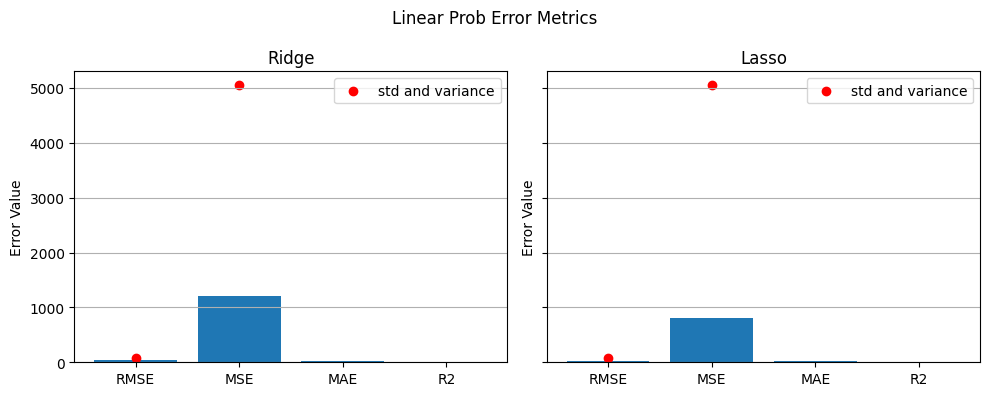

In [51]:
fig, axs = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)

for ax, (name, model) in zip(axs, models.items()):
    plot_model_metrics(ax, X, z, model, name, overlay_values=baselines)

plt.suptitle("Linear Prob Error Metrics")
plt.tight_layout()
plt.show()